# 7 · Price impact: how much does trading move the price?

**The questions:**
1. If an order is 10x bigger, does it move the price 10x more?
2. Does the impact last, or fade?
3. If I need to buy 1,000 BTC, what will it cost me?

Impact is the single most important number for anyone who trades size. It decides how big a fund can get
before its costs eat its alpha, how to split a large order, and how market makers set their quotes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from micro.data import load_quotes, load_trades, aggregate_trades
from micro.book import mid, to_ms, resample_last, sum_in_buckets, time_grid
from micro.impact import mid_at, response_function
from micro.stats import binned_mean, loglog_slope, ols
from micro.volatility import signature_plot
from micro.plotting import style, save, BLUE, ORANGE, GREEN, GREY, RED

style()
quotes = load_quotes()
trades = load_trades()
orders = aggregate_trades(trades)
qts, m = to_ms(quotes.ts), mid(quotes)
ots, sign, qty = to_ms(orders.ts), orders.sign.to_numpy(), orders.qty.to_numpy()
m0 = mid_at(qts, m, ots, strictly_before=True)      # mid just before each order

## 1. Impact of a single order vs its size

Impact of order n at horizon h: I_n(h) = s_n · (mid_{t+h} − mid_{before}). Positive = the price moved in the
direction of the trade. We average within log-spaced size bins.

h =    0s   fitted exponent (0.01-20 BTC) = 0.58
h =    1s   fitted exponent (0.01-20 BTC) = 0.40


h =   10s   fitted exponent (0.01-20 BTC) = 0.32


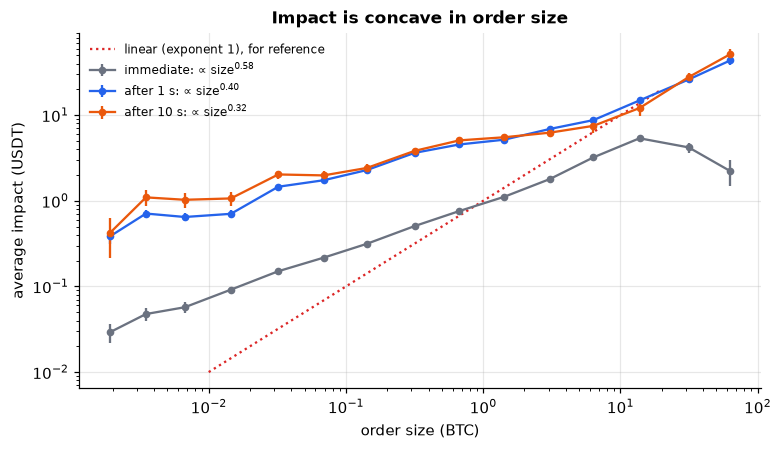

In [2]:
size_bins = np.logspace(-3, 2, 16)
fig, ax = plt.subplots()
for h, color in [(0, GREY), (1000, BLUE), (10_000, ORANGE)]:
    mh = mid_at(qts, m, ots + np.timedelta64(h, "ms"))
    b = binned_mean(qty, sign * (mh - m0), size_bins)
    b = b[b["count"] > 200]
    sel = (b.x_mean > 0.01) & (b.x_mean < 20)
    slope, c = loglog_slope(b.x_mean[sel], b.y_mean[sel])
    ax.errorbar(b.x_mean, b.y_mean, yerr=1.96 * b.y_se, fmt="o-", ms=4, color=color,
                label=f"{'immediate' if h == 0 else f'after {h // 1000} s'}: ∝ size$^{{{slope:.2f}}}$")
    print(f"h = {h / 1000:>4g}s   fitted exponent (0.01-20 BTC) = {slope:.2f}")
xs = np.logspace(-2, 1.3, 10)
ax.plot(xs, 1.0 * xs, ":", color=RED, label="linear (exponent 1), for reference")
ax.set(xscale="log", yscale="log", xlabel="order size (BTC)", ylabel="average impact (USDT)",
       title="Impact is concave in order size")
ax.legend(fontsize=8)
save(fig, "07_impact_vs_size")

Impact grows like **size^0.3–0.6** (steeper immediately, flatter after 10 s), never linearly. A 100x bigger
order moves the price only about 5–15x more. This **concavity** is one of the most robust facts in microstructure, in every market studied.

Two reasons:
- **Selective liquidity taking**: traders send big market orders when there's a lot of liquidity
  available, and small ones when the book is thin. Look at the grey (immediate) curve: the very largest
  orders (30+ BTC) have *smaller* immediate impact than 10 BTC orders. They were timed to hit deep books.
- **The book refills**: after a big order eats through the queue, liquidity providers step back in.

## 2. Does impact last? The response function

Follow the price in **trade time**: R(ℓ) = E[s_n · (mid before order n+ℓ − mid before order n)].

R(1) = 0.32,  peak R = 2.02 at lag 167,  R(20000) = -0.18


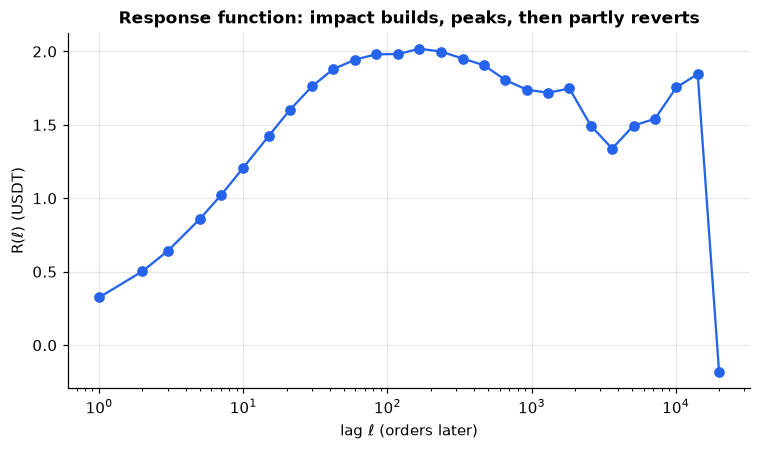

In [3]:
lags = np.unique(np.logspace(0, np.log10(20_000), 30).astype(int))
R = response_function(sign, m0, lags)
fig, ax = plt.subplots()
ax.semilogx(lags, R, "o-", color=BLUE)
ax.set(xlabel="lag ℓ (orders later)", ylabel="R(ℓ) (USDT)", title="Response function: impact builds, peaks, then partly reverts")
save(fig, "07_response_function")
print(f"R(1) = {R[0]:.2f},  peak R = {R.max():.2f} at lag {lags[R.argmax()]},  R({lags[-1]}) = {R[-1]:.2f}")

R(ℓ) keeps rising for ~100 orders after the trade. That's not the trade itself acting slowly. It's the
*other* orders that follow in the same direction (order flow is persistent, chapter 2). Then it peaks and
drifts back toward zero: much of the impact is **transient**. (Beyond a few thousand orders the estimate gets
noisy. It averages price changes over 10–20 minutes, whose standard deviation is hundreds of USDT, so "fully
reverts" and "partly reverts" can't be told apart from one day.)

This shape resolves chapter 2's efficiency paradox. If each trade had a fixed permanent impact, persistent
order flow would make prices trend predictably. Instead impact partly decays, at just the right rate to
offset the persistence of flow. That's the **propagator model** of Bouchaud, Gefen, Potters & Wyart (2004):
p_t = Σ G(t − n)·s_n with a decaying kernel G, tuned so that returns stay unpredictable.

## 3. Kyle's lambda: impact of aggregate order flow

In Kyle's (1985) model a market maker sets prices linearly in net order flow:
Δprice = λ · (net signed volume). λ (lambda) is the classic measure of **illiquidity**: USDT of price
move per BTC of net buying.

In [4]:
rows = []
for f in ["10s", "1min", "5min", "15min"]:
    grid = time_grid(qts[0], qts[-1], f)
    dmid = np.diff(resample_last(qts, m, grid))
    Q = sum_in_buckets(ots, sign * qty, grid)
    ok = ~np.isnan(dmid)
    r = ols(dmid[ok], Q[ok], hac_lags=5, names=["net volume"])
    rows.append({"interval": f, "n": int(ok.sum()), "lambda (USDT per BTC)": r.beta[1], "t": r.t[1], "R2": r.r2})
print(pd.DataFrame(rows).set_index("interval").round(3))

             n  lambda (USDT per BTC)       t     R2
interval                                            
10s       8639                  0.301  14.303  0.370
1min      1439                  0.287   8.518  0.528
5min       287                  0.294  18.375  0.679
15min       95                  0.348  25.095  0.857


λ ≈ 0.3 USDT per BTC of net buying (0.29–0.35), roughly the same from 10 s to 15 minutes. And R² *rises* with the
interval. At longer horizons, net order flow explains most of the price change.

Careful with the comparison to part 1: a single 1 BTC order moves the price ~5 USDT within a second, far
more than λ × 1 = 0.3. No contradiction. Concave single-order impact plus partial reversion means
**aggregated** impact is much flatter and closer to linear than individual-order impact. Impact "per BTC"
depends on how you slice time.

## 4. The square-root law, and a worked example

For a **metaorder** (a big order split into many pieces and executed over hours), decades of data from
institutional brokers show

$$\Delta P \approx Y \cdot \sigma_{\text{daily}} \cdot \sqrt{\frac{Q}{V_{\text{daily}}}}$$

where Q is the metaorder size, V the daily volume, and Y a constant of order 1. This is the **square-root
impact law**. We can't test it here because public data doesn't say which trades belong to the same
metaorder. You need a broker's or fund's own execution records. But we can *use* it with our numbers.

In [5]:
sigma_daily = np.sqrt(signature_plot(qts, m, ["5min"])["5min"])
V = trades.qty.sum()
price = m.mean()
print(f"daily vol (5-min RV): {sigma_daily:.2%},   daily volume: {V:,.0f} BTC,   price ≈ {price:,.0f} USDT")
for Q in [10, 100, 1_000, 10_000]:
    impact = 1.0 * sigma_daily * np.sqrt(Q / V)
    print(f"buy {Q:>6,} BTC (${Q * price / 1e6:>6,.0f}m, {Q / V:6.2%} of daily volume): impact ≈ {impact:.3%} "
          f"≈ {impact * price:,.0f} USDT/BTC, total cost ≈ ${impact * price * Q:,.0f}")

daily vol (5-min RV): 3.15%,   daily volume: 407,758 BTC,   price ≈ 69,782 USDT
buy     10 BTC ($     1m,  0.00% of daily volume): impact ≈ 0.016% ≈ 11 USDT/BTC, total cost ≈ $109
buy    100 BTC ($     7m,  0.02% of daily volume): impact ≈ 0.049% ≈ 34 USDT/BTC, total cost ≈ $3,443
buy  1,000 BTC ($    70m,  0.25% of daily volume): impact ≈ 0.156% ≈ 109 USDT/BTC, total cost ≈ $108,866
buy 10,000 BTC ($   698m,  2.45% of daily volume): impact ≈ 0.493% ≈ 344 USDT/BTC, total cost ≈ $3,442,649


The square root makes impact cost per unit grow as √Q, so **total** cost grows like Q^1.5. Going from
1,000 to 10,000 BTC makes each BTC ~3.2x more expensive to buy. This is why capacity limits every strategy:
returns per dollar fall as the fund grows.

---
### Interview angle

<details><summary><b>"Buying 1% of daily volume costs 10 bp of impact. What does buying 4% cost?"</b></summary>

Square-root law: impact ∝ √(Q/V), so 4x the size gives 2x the impact per share = 20 bp. Total cost (impact ×
quantity) is 8x. Linear models would say 40 bp and 16x. Concavity matters a lot for sizing.
</details>

<details><summary><b>"Why is price impact concave?"</b></summary>

Selective liquidity taking (big orders are sent when liquidity is plentiful), liquidity refilling after big
trades, and in the metaorder setting, latent liquidity that only reveals itself once the price moves
(Tóth et al. 2011's "latent order book" explanation of the square root).
</details>

<details><summary><b>"What's Kyle's lambda and how would you estimate it?"</b></summary>

The slope of price changes on net signed order flow: an illiquidity measure, Δp = λ·Q. Estimate by
regressing interval mid changes on net signed volume, with robust (HAC) standard errors. In Kyle's model
λ = σ_v / (2σ_u): more fundamental uncertainty or less noise trading means a steeper λ.
</details>

### Try this yourself
1. Estimate λ for each hour. Is the market less liquid (higher λ) in quiet hours? Relate it to the depth plot in chapter 5.
2. Split orders by whether they *continued* the previous order's sign or *reversed* it. Which has more impact? (Lillo & Farmer's "surprise" effect.)